# 04 — Regression: predicting annual energy cost

We predict `TOTALDOL` (annual energy expenditure in USD) using two models with different purposes:

1. **Elastic Net regression** — the regularized linear baseline. It handles correlated OHE features, is fast, and gives a defensible coefficient story.
2. **Gradient Boosting regression** — the nonlinear tabular model. It captures interactions such as climate × heating fuel × square footage that a linear model cannot represent directly.

Both use the same train/test split saved by `03_classification` and the same feature partition. All final evaluation metrics use `sample_weight = NWEIGHT_test` so they reflect U.S.-population RMSE/MAE/R², not sample-level error.

The original proposal included SVR. We replaced it because kernel SVR scales poorly at 14,796 training rows after one-hot encoding and does not naturally give the interpretability or runtime profile we need for a course project. We also avoid neural networks because this is modest-sized tabular survey data where reproducibility and explanation matter more than model capacity.


## Setup

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


def load_clean_recs(data_dir):
    parquet_path = os.path.join(data_dir, 'recs2020_clean.parquet')
    pickle_path = os.path.join(data_dir, 'recs2020_clean.pkl')
    if os.path.exists(parquet_path):
        return pd.read_parquet(parquet_path)
    return pd.read_pickle(pickle_path)

df = load_clean_recs(DATA_DIR)
print('shape:', df.shape)


shape: (18495, 69)


## Restore the train/test split from 03

Same DOEIDs go to train/test in classification and regression so the recommendation layer can join predictions cleanly.

In [2]:
split_path = os.path.join(DATA_DIR, 'train_test_split.json')
split = json.load(open(split_path))
train_doeid = set(split['train_doeid'])
test_doeid  = set(split['test_doeid'])

train_mask = df['DOEID'].isin(train_doeid)
test_mask  = df['DOEID'].isin(test_doeid)
print(f'train: {train_mask.sum():,}    test: {test_mask.sum():,}')


train: 14,796    test: 3,699


## Feature partition

Same as `03_classification`. Numerics get sentinels → NaN → median impute → standard scale. Categoricals get one-hot (sentinels become their own dummy column).

In [3]:
CATEGORICAL = [
    'BA_climate_grp','REGIONC','DIVISION','state_postal','TYPEHUQ','WALLTYPE','ROOFTYPE',
    'EQUIPM','FUELHEAT','TYPETHERM','FUELH2O','TYPERFR1','RANGEFUEL','TOPFRONT','WASHTEMP','EMPLOYHH',
    'AIRCOND','CWASHER','DISHWASH','HIGHCEIL',
    'STORIES','AGEDW','AGECWASH','EQUIPAGE','ORIGWIN','WINFRAME',
]
NUMERIC = [
    'HDD65','CDD65','TOTSQFT_EN','BEDROOMS','TOTROOMS','NCOMBATH','NHAFBATH',
    'WINDOWS','SIZRFRI1','WHEATSIZ','NUMFRIG','TEMPHOME','TEMPGONE','TEMPNITE',
    'NHSLDMEM','HHAGE',
    'LGTIN1TO4','LGTIN4TO8','LGTINMORE8','LGTINLED','LGTINCFL','LGTINCAN',
    'ADQINSUL','DRAFTY','TYPEGLASS','YEARMADERANGE','WHEATAGE','AGERFRI1','TREESHAD',
]
SENTINELS = [-2, -9]
TARGET = 'TOTALDOL'
WEIGHT = 'NWEIGHT'

X = pd.concat([
    df[NUMERIC].replace({s: np.nan for s in SENTINELS}),
    df[CATEGORICAL].astype(str),
], axis=1)
y = df[TARGET]
w = df[WEIGHT]

X_train, y_train, w_train = X[train_mask], y[train_mask], w[train_mask]
X_test,  y_test,  w_test  = X[test_mask],  y[test_mask],  w[test_mask]
print(f'X_train: {X_train.shape},   y_train mean ${y_train.mean():.0f}')
print(f'X_test:  {X_test.shape},    y_test mean ${y_test.mean():.0f}')


X_train: (14796, 55),   y_train mean $1988
X_test:  (3699, 55),    y_test mean $1998


## Shared preprocessing

In [4]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
categorical_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe,    NUMERIC),
    ('cat', categorical_pipe, CATEGORICAL),
])
# sparse_output=False because GradientBoostingRegressor does not accept sparse input.


## Weighted metrics

In [5]:
def weighted_metrics(y_true, y_pred, sample_weight, label=''):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred, sample_weight=sample_weight)))
    mae  = float(mean_absolute_error(y_true, y_pred, sample_weight=sample_weight))
    r2   = float(r2_score(y_true, y_pred, sample_weight=sample_weight))
    if label:
        print(f'  {label:25s} RMSE ${rmse:>8.0f}   MAE ${mae:>8.0f}   R² {r2:.4f}')
    return rmse, mae, r2


## Model 1 — Elastic Net with grid search

`alpha` controls overall regularization strength; `l1_ratio` mixes L1 (sparse selection) and L2 (smooth shrinkage). This is the baseline we can explain cleanly: after scaling and OHE, coefficients show directional effects while regularization prevents unstable weights across correlated survey variables.


In [6]:
enet = Pipeline([
    ('pre', preprocess),
    ('reg', ElasticNet(max_iter=20000, random_state=42)),
])

enet_grid = {
    'reg__alpha':    [0.1, 1.0, 10.0, 100.0],
    'reg__l1_ratio': [0.1, 0.5, 0.9],
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
enet_search = GridSearchCV(
    enet, enet_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv, n_jobs=-1, verbose=1,
)
t0 = time.time()
enet_search.fit(X_train, y_train, reg__sample_weight=w_train.values)
print(f'fit time: {time.time()-t0:.1f}s')
print(f'best params: {enet_search.best_params_}')
print(f'best CV neg-RMSE: {enet_search.best_score_:.2f}  (RMSE ${-enet_search.best_score_:.0f})')


Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/h

/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/h

/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/h

...

/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/h

/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/h

/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/h

/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/h

fit time: 4.8s
best params: {'reg__alpha': 0.1, 'reg__l1_ratio': 0.9}
best CV neg-RMSE: -794.90  (RMSE $795)


## Model 2 — Gradient Boosting

Gradient Boosting is the stronger tabular regression candidate because it learns nonlinear interactions without manually creating every cross-feature. That matters here: the effect of square footage, heating fuel, cooling degree days, and climate zone is not purely additive. We tune lightly via 3-fold CV on `n_estimators` and `learning_rate` to keep runtime reasonable.


In [7]:
gbr = Pipeline([
    ('pre', preprocess),
    ('reg', GradientBoostingRegressor(
        max_depth=4,
        random_state=42,
    )),
])

gbr_grid = {
    'reg__n_estimators':  [200, 400],
    'reg__learning_rate': [0.05, 0.1],
}
gbr_search = GridSearchCV(
    gbr, gbr_grid,
    scoring='neg_root_mean_squared_error',
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1,
)
t0 = time.time()
gbr_search.fit(X_train, y_train, reg__sample_weight=w_train.values)
print(f'fit time: {time.time()-t0:.1f}s')
print(f'best params: {gbr_search.best_params_}')
print(f'best CV neg-RMSE: {gbr_search.best_score_:.2f}  (RMSE ${-gbr_search.best_score_:.0f})')


Fitting 3 folds for each of 4 candidates, totalling 12 fits


fit time: 72.7s
best params: {'reg__learning_rate': 0.05, 'reg__n_estimators': 400}
best CV neg-RMSE: -772.03  (RMSE $772)


## Test-set evaluation

In [8]:
enet_best = enet_search.best_estimator_
gbr_best  = gbr_search.best_estimator_

y_pred_enet = enet_best.predict(X_test)
y_pred_gbr  = gbr_best.predict(X_test)

# Naive baseline: predict the (weighted) mean of TOTALDOL on the train set
mean_pred = float(np.average(y_train, weights=w_train))
y_pred_mean = np.full_like(y_test, mean_pred, dtype=float)

print('Test-set performance (weighted by NWEIGHT):')
weighted_metrics(y_test, y_pred_mean, w_test, 'Mean baseline')
weighted_metrics(y_test, y_pred_enet, w_test, 'Elastic Net')
weighted_metrics(y_test, y_pred_gbr,  w_test, 'Gradient Boosting')


Test-set performance (weighted by NWEIGHT):
  Mean baseline             RMSE $    1063   MAE $     762   R² -0.0000
  Elastic Net               RMSE $     752   MAE $     505   R² 0.4996
  Gradient Boosting         RMSE $     745   MAE $     494   R² 0.5090


/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


(744.836032521627, 493.8556910325916, 0.5090043760970728)

## Residual diagnostics

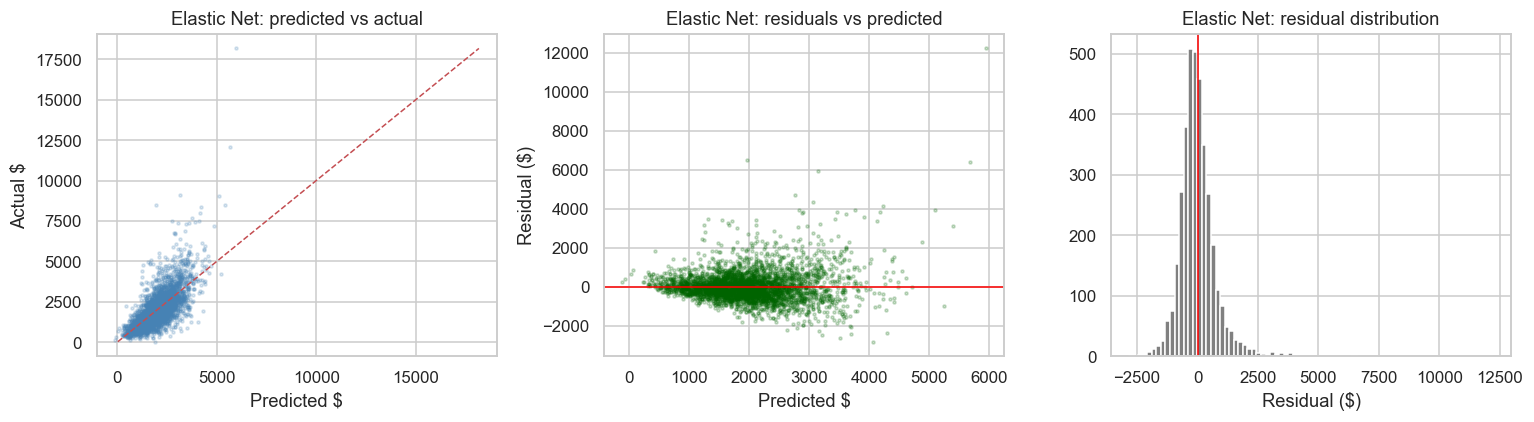

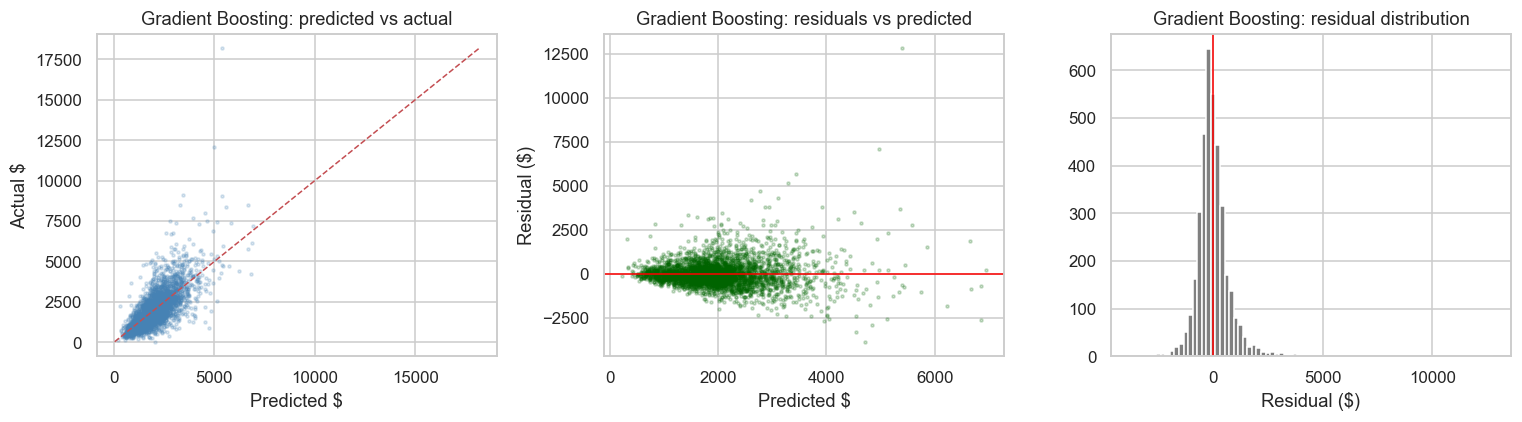

In [9]:
def diag_plots(y_true, y_pred, title):
    resid = y_true - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Predicted vs actual
    axes[0].scatter(y_pred, y_true, s=4, alpha=0.2, color='steelblue')
    lo, hi = y_true.min(), y_true.max()
    axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    axes[0].set_xlabel('Predicted $')
    axes[0].set_ylabel('Actual $')
    axes[0].set_title(f'{title}: predicted vs actual')

    # Residual vs predicted
    axes[1].scatter(y_pred, resid, s=4, alpha=0.2, color='darkgreen')
    axes[1].axhline(0, color='red', linewidth=1)
    axes[1].set_xlabel('Predicted $')
    axes[1].set_ylabel('Residual ($)')
    axes[1].set_title(f'{title}: residuals vs predicted')

    # Residual histogram
    axes[2].hist(resid, bins=80, color='gray', edgecolor='white')
    axes[2].axvline(0, color='red', linewidth=1)
    axes[2].set_xlabel('Residual ($)')
    axes[2].set_title(f'{title}: residual distribution')
    plt.tight_layout()
    plt.show()

diag_plots(y_test.values, y_pred_enet, 'Elastic Net')
diag_plots(y_test.values, y_pred_gbr,  'Gradient Boosting')


## Outlier audit

RMSE is sensitive to a small number of very high annual bills. This table surfaces the largest Gradient Boosting residuals so the report can explain where the model is still weak instead of only reporting aggregate metrics.


In [10]:
residual_audit = pd.DataFrame({
    'DOEID': df.loc[X_test.index, 'DOEID'].values,
    'BA_climate_grp': df.loc[X_test.index, 'BA_climate_grp'].values,
    'TOTSQFT_EN': df.loc[X_test.index, 'TOTSQFT_EN'].values,
    'cost_per_sqft': df.loc[X_test.index, 'cost_per_sqft'].values,
    'actual_TOTALDOL': y_test.values,
    'pred_gbr': y_pred_gbr,
})
residual_audit['residual_gbr'] = residual_audit['actual_TOTALDOL'] - residual_audit['pred_gbr']
residual_audit['abs_residual_gbr'] = residual_audit['residual_gbr'].abs()

residual_audit.sort_values('abs_residual_gbr', ascending=False).head(10)


,DOEID,BA_climate_grp,TOTSQFT_EN,cost_per_sqft,actual_TOTALDOL,pred_gbr,residual_gbr,abs_residual_gbr
1654,108344,Cold,15000,1.211793,18176.89,5387.085004,12789.804996,12789.804996
1326,106662,Hot-Humid,4670,2.587760,12084.84,4978.958381,7105.881619,7105.881619
2129,110722,Hot-Humid,4400,2.066670,9093.35,3443.651646,5649.698354,5649.698354
2654,113203,Mixed-Humid,1010,8.385455,8469.31,3300.529280,5168.780720,5168.780720
3693,118456,Mixed-Dry,2000,3.742385,7484.77,2766.607330,4718.162670,4718.162670
1019,105205,Cold,3400,2.177247,7402.64,3100.987814,4301.652186,4301.652186
2559,112726,Hot-Humid,2500,2.709568,6773.92,2613.781138,4160.138862,4160.138862
1033,105251,Hot-Dry,6100,0.142134,867.02,4720.603037,-3853.583037,3853.583037
535,102960,Cold,1200,5.563108,6675.73,2858.693002,3817.036998,3817.036998
2571,112755,Cold,3150,2.136911,6731.27,2947.571634,3783.698366,3783.698366


## Feature importance

Elastic Net: standardized coefficients (since features are scaled, magnitudes are directly comparable).
Gradient Boosting: impurity-based `feature_importances_`.

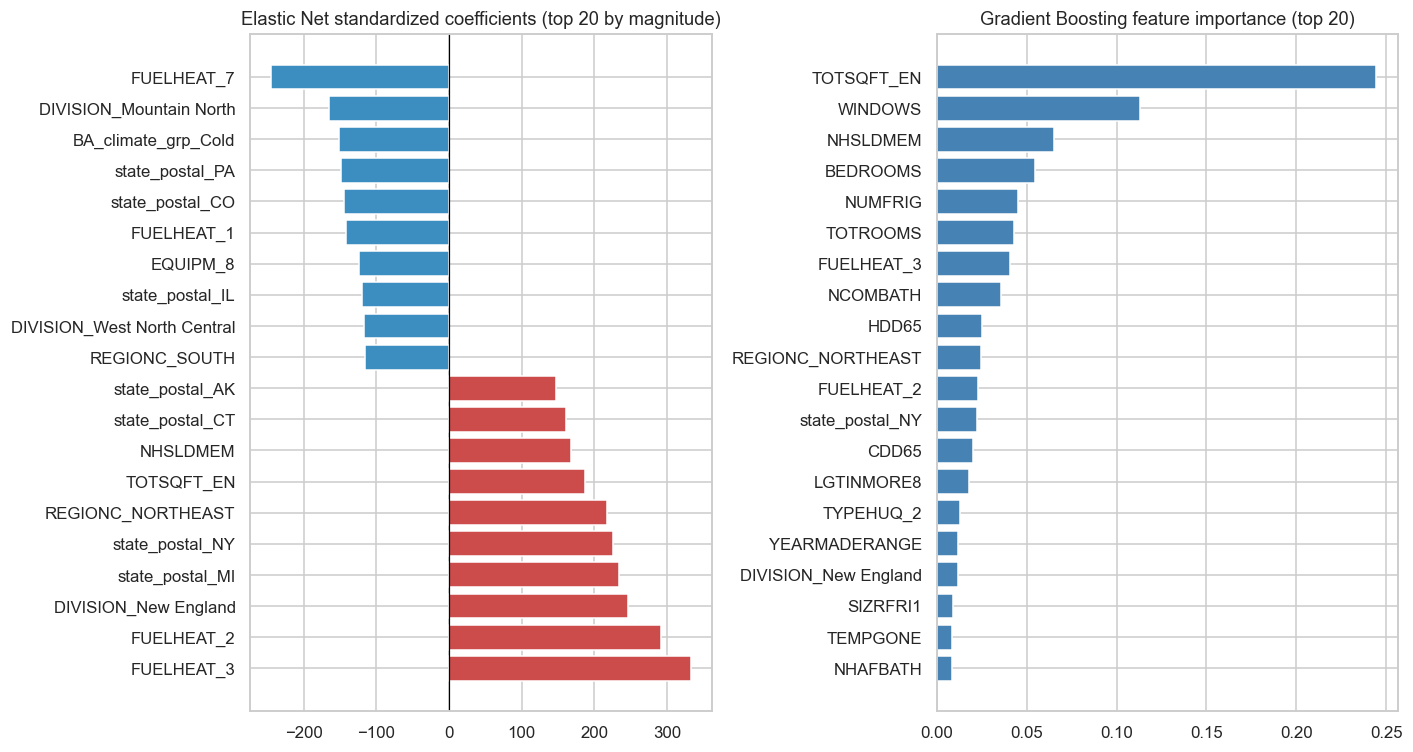

In [11]:
# Recover output feature names
ohe = enet_best.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
ohe_names = ohe.get_feature_names_out(CATEGORICAL).tolist()
all_feature_names = list(NUMERIC) + ohe_names

enet_coefs = enet_best.named_steps['reg'].coef_
gbr_imp    = gbr_best.named_steps['reg'].feature_importances_

enet_imp_s = pd.Series(enet_coefs, index=all_feature_names).sort_values()
gbr_imp_s  = pd.Series(gbr_imp,    index=all_feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
top_e = pd.concat([enet_imp_s.head(10), enet_imp_s.tail(10)])
colors_e = ['#3c8ec0' if v < 0 else '#cc4c4c' for v in top_e.values]
axes[0].barh(top_e.index, top_e.values, color=colors_e)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()
axes[0].set_title('Elastic Net standardized coefficients (top 20 by magnitude)')

top_g = gbr_imp_s.head(20)
axes[1].barh(top_g.index, top_g.values, color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Gradient Boosting feature importance (top 20)')
plt.tight_layout()
plt.show()


## Save fitted models and predictions

In [12]:
joblib.dump(enet_best, os.path.join(MODELS_DIR, 'elasticnet_regression.joblib'))
joblib.dump(gbr_best,  os.path.join(MODELS_DIR, 'gbr_regression.joblib'))

predictions = pd.DataFrame({
    'DOEID':         df.loc[X_test.index, 'DOEID'].values,
    'BA_climate_grp':df.loc[X_test.index, 'BA_climate_grp'].values,
    'NWEIGHT':       w_test.values,
    'TOTALDOL_true': y_test.values,
    'pred_enet':     y_pred_enet,
    'pred_gbr':      y_pred_gbr,
})
predictions.to_csv(os.path.join(MODELS_DIR, 'regression_test_predictions.csv'), index=False)
print('saved:', os.path.join(MODELS_DIR, 'elasticnet_regression.joblib'))
print('saved:', os.path.join(MODELS_DIR, 'gbr_regression.joblib'))
print('saved:', os.path.join(MODELS_DIR, 'regression_test_predictions.csv'))
predictions.head()


saved: /Users/krishgarg/Documents/CPSC_COURSES/CPSC393/final/CPSC393/models/elasticnet_regression.joblib
saved: /Users/krishgarg/Documents/CPSC_COURSES/CPSC393/final/CPSC393/models/gbr_regression.joblib
saved: /Users/krishgarg/Documents/CPSC_COURSES/CPSC393/final/CPSC393/models/regression_test_predictions.csv


,DOEID,BA_climate_grp,NWEIGHT,TOTALDOL_true,pred_enet,pred_gbr
0,100001,Mixed-Dry,3284.103668,2656.89,2071.722289,2201.146190
1,100003,Mixed-Dry,5669.002142,522.65,625.688109,531.709518
2,100020,Hot-Humid,5876.501535,1549.78,1993.282177,2123.916771
3,100023,Cold,2147.068599,2922.94,3341.461431,3698.197410
4,100024,Cold,1997.948751,1142.86,1783.076058,1808.561618


## Summary

- Both learned models beat the weighted mean baseline by a wide margin on RMSE, MAE, and R².
- Gradient Boosting is the main regression model because it captures nonlinear interactions such as climate × heating fuel × square footage and achieves the best held-out RMSE/R².
- Elastic Net remains useful as the interpretable baseline: it tells us whether the nonlinear model is actually improving over a regularized linear approach.
- SVR was intentionally dropped for scalability, and neural networks were intentionally avoided because the dataset is tabular, modest-sized, and explanation-focused.
- The largest remaining errors are high-bill outliers. That limitation should be discussed with MAE and residual plots, not hidden behind a single RMSE number.
